In [24]:
import numpy as np
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
import matplotlib.pyplot as plt
import os 
import numpy as np
from sklearn.cluster import DBSCAN
from DBSCAN_utils import *
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
RR=data_importation()

In [3]:
RR.shape

(288, 300, 300)

## approche par PDynamique // test matrice d'adjacence

44.75999999999992 28.067681999999994


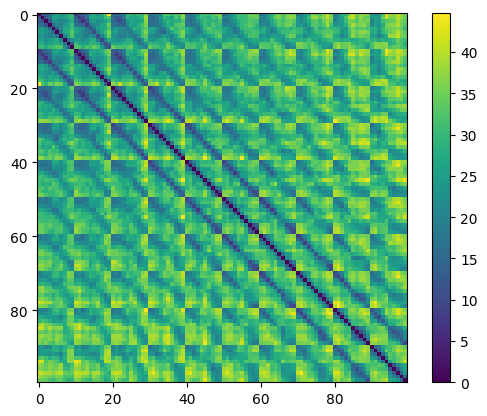

In [5]:
distance_matrix = calculate_distance_matrix(RR, 0, 10, 0, 10, dtw_distance)
print(distance_matrix.max(),distance_matrix.mean())
plt.imshow(distance_matrix)
plt.colorbar()

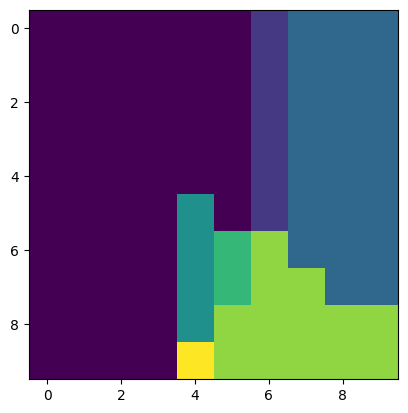

In [6]:
dbscan_dynamic = DBSCAN(eps=15, min_samples=1, metric='precomputed')
dbscan_dynamic.fit(distance_matrix)
labels=dbscan_dynamic.labels_
plt.imshow(labels.reshape(10,10))

## approche classic par DBSCAN SKLEARN

## Sliding window

In [7]:
longitude_max = 2
latitude_max = 2
step = 9
width = 10

la case en dessous prends 4 min de calcule a voir si necessaire tout les resultats sont obtenables apres

In [6]:
dict_clusters,dict_labels,core_points=DBSCAN_Slinding_Window(RR,longitude_max = 2,latitude_max = 2,step = 9,width = 10,eps=10,min_samples=1,metric=dtw_distance)

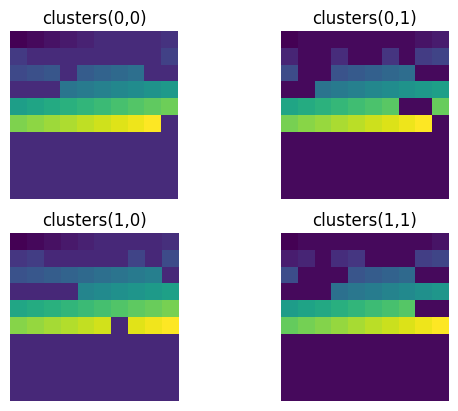

In [7]:
affichage_clusters(dict_labels,longitude_max,latitude_max)

# sauvegarde de matrice 50*50 km et exemple d'appel d'info

In [8]:
longitude_max = 5
latitude_max = 5
step = 9
width = 10

a ne pas faire tourner la case juste en dessous prends 33min (données sauvegardées deja)

In [ ]:
d = {}
for i in range(5):
    for j in range(5):
        d[f"distance_matrix{i},{j}"] = calculate_distance_matrix(
            RR, i * step, width + i * step, j * step, width + j * step, dtw_distance
        )

# Save the dictionary to a file
import pickle
with open(f'distance_matrices_width={width}_step={step}_longitude={longitude_max}_latitude={latitude_max}.pkl', 'wb') as f:
    pickle.dump(d, f)


In [9]:

# Load the dictionary from the file
with open(f'distance_matrices_width={width}_step={step}.pkl', 'rb') as f:
    d_loaded = pickle.load(f)

# Example: Access the distance matrix for the (2,3) position
key = "distance_matrix2,3"
if key in d_loaded:
    matrix = d_loaded[key]
    print(key)
    print(matrix)
else:
    print(f"No distance matrix found for key {key}")


distance_matrix2,3
[[  0.    23.25  35.85 ... 103.97  78.19  61.16]
 [ 23.25   0.    26.54 ...  85.65  66.7   54.11]
 [ 35.85  26.54   0.   ...  86.95  64.64  45.22]
 ...
 [103.97  85.65  86.95 ...   0.    39.22  77.69]
 [ 78.19  66.7   64.64 ...  39.22   0.    47.43]
 [ 61.16  54.11  45.22 ...  77.69  47.43   0.  ]]


# TEST a faire utilisé directement pour voir les parametres

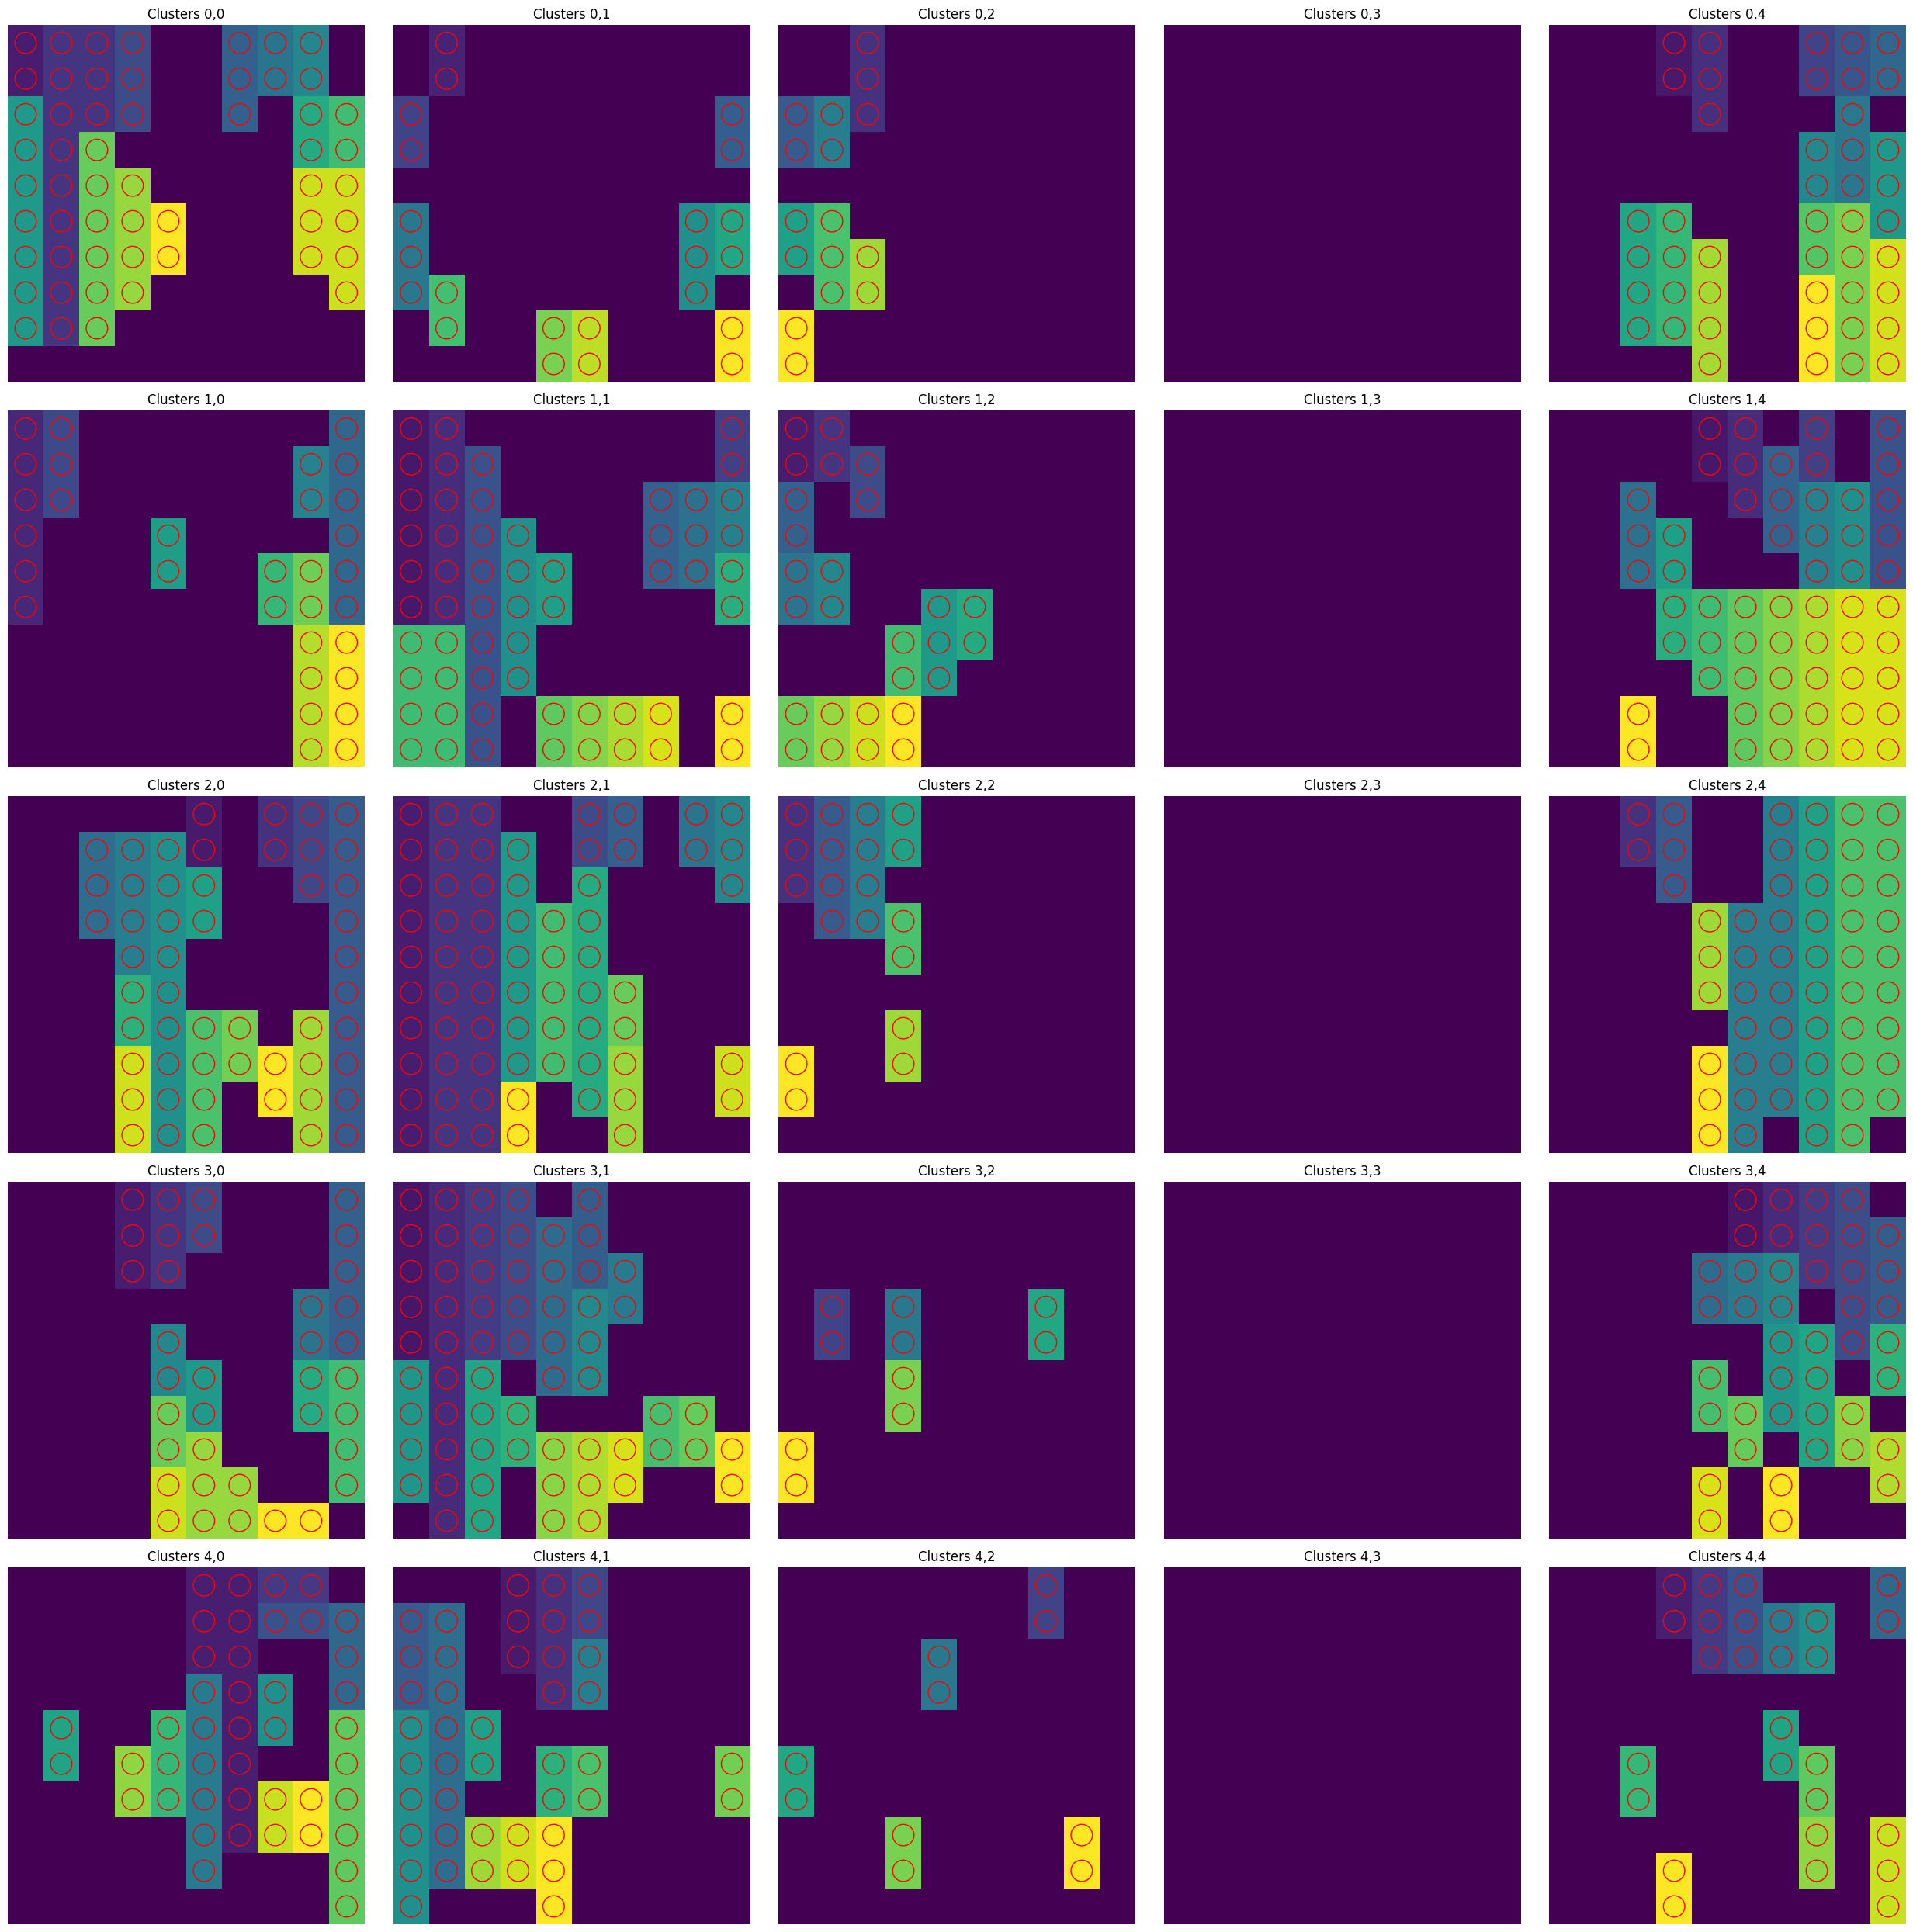

In [10]:
dict_clusters,dict_labels,core_points=DBSCAN_DP(longitude_max = longitude_max,latitude_max = latitude_max,step=step,width=width,eps=10,min_samples=2)
affichage_clusters_enhanced(dict_labels,core_points,longitude_max,latitude_max,width)

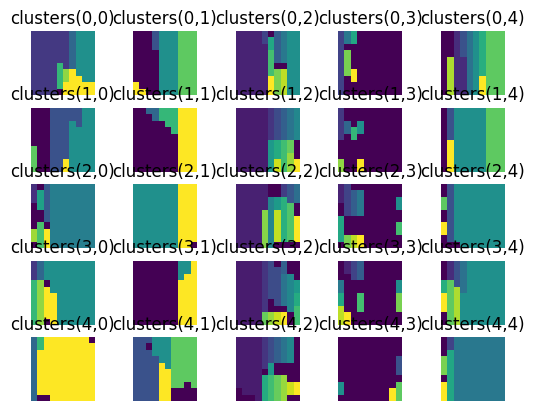

In [11]:
dict_clusters,dict_labels,core_points=DBSCAN_DP(longitude_max = longitude_max,latitude_max = latitude_max,step=step,width=width,eps=15,min_samples=2)
affichage_clusters(dict_labels,longitude_max,latitude_max)

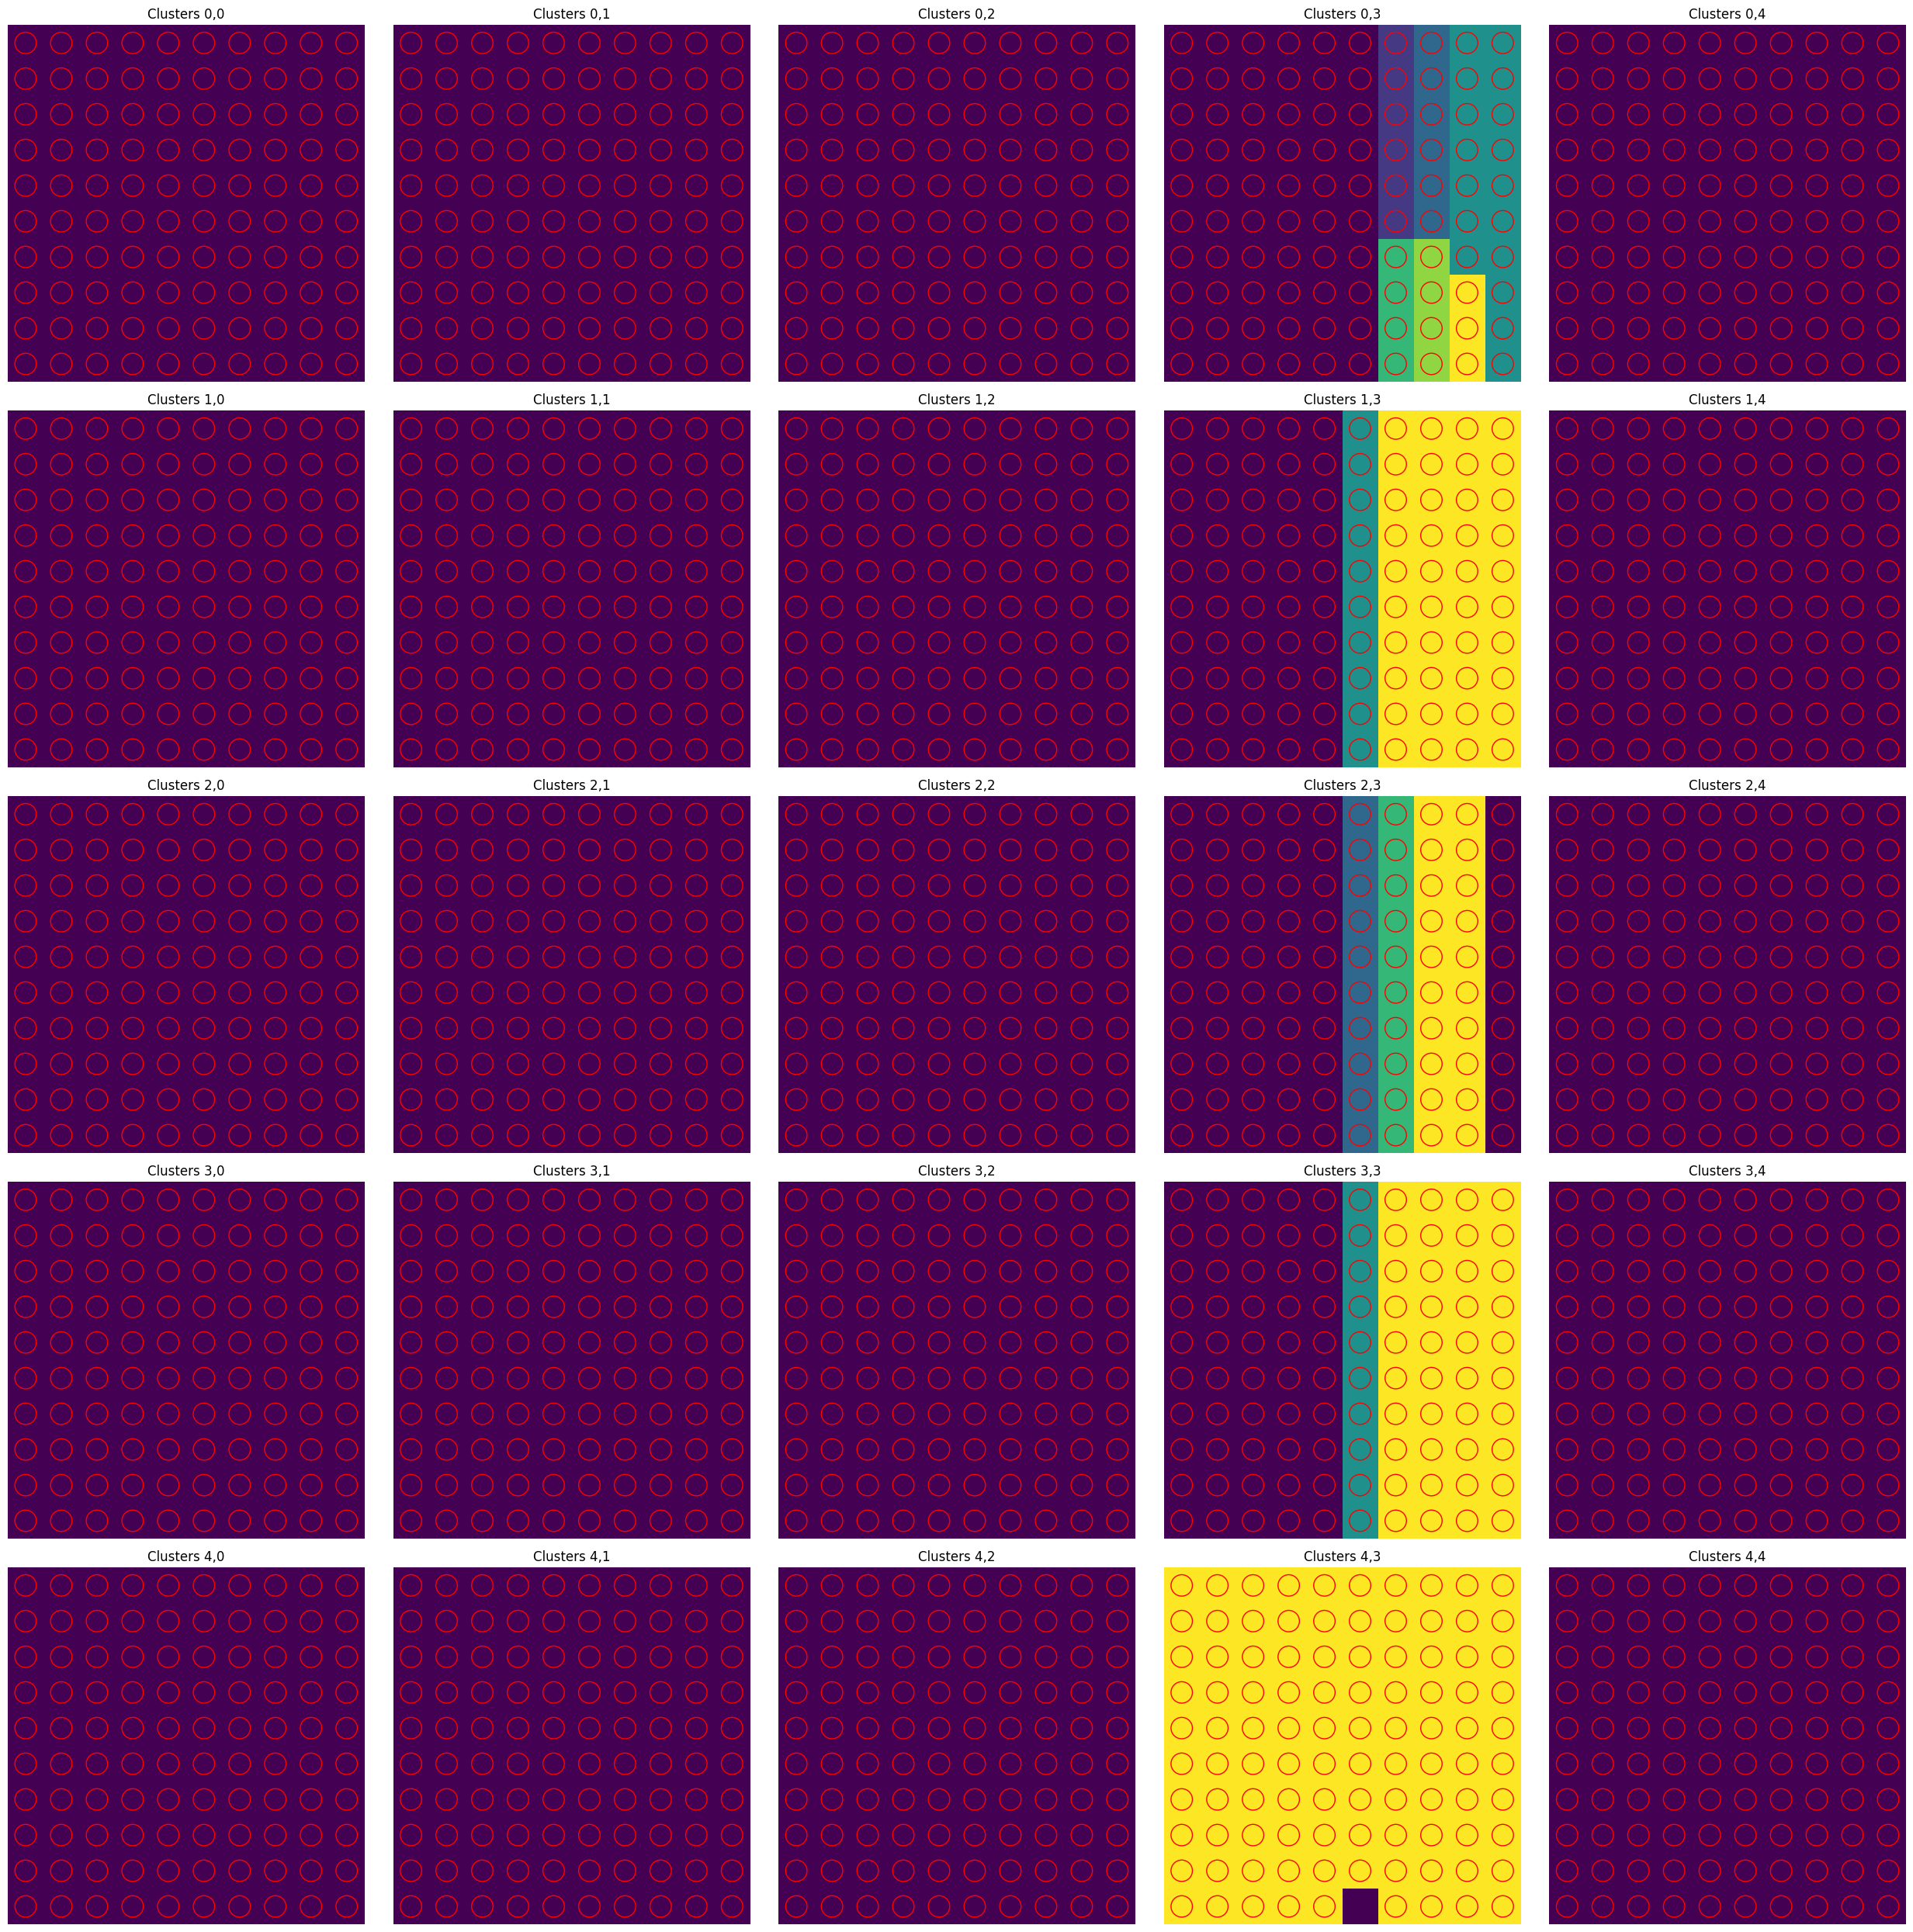

In [12]:
dict_clusters,dict_labels,core_points=DBSCAN_DP(longitude_max = longitude_max,latitude_max = latitude_max,step=step,width=width,eps=40,min_samples=2)
affichage_clusters_enhanced(dict_labels,core_points,longitude_max,latitude_max,width)

# organisation clusters et jointure entre les elements

je prends ce clustering comme exemple

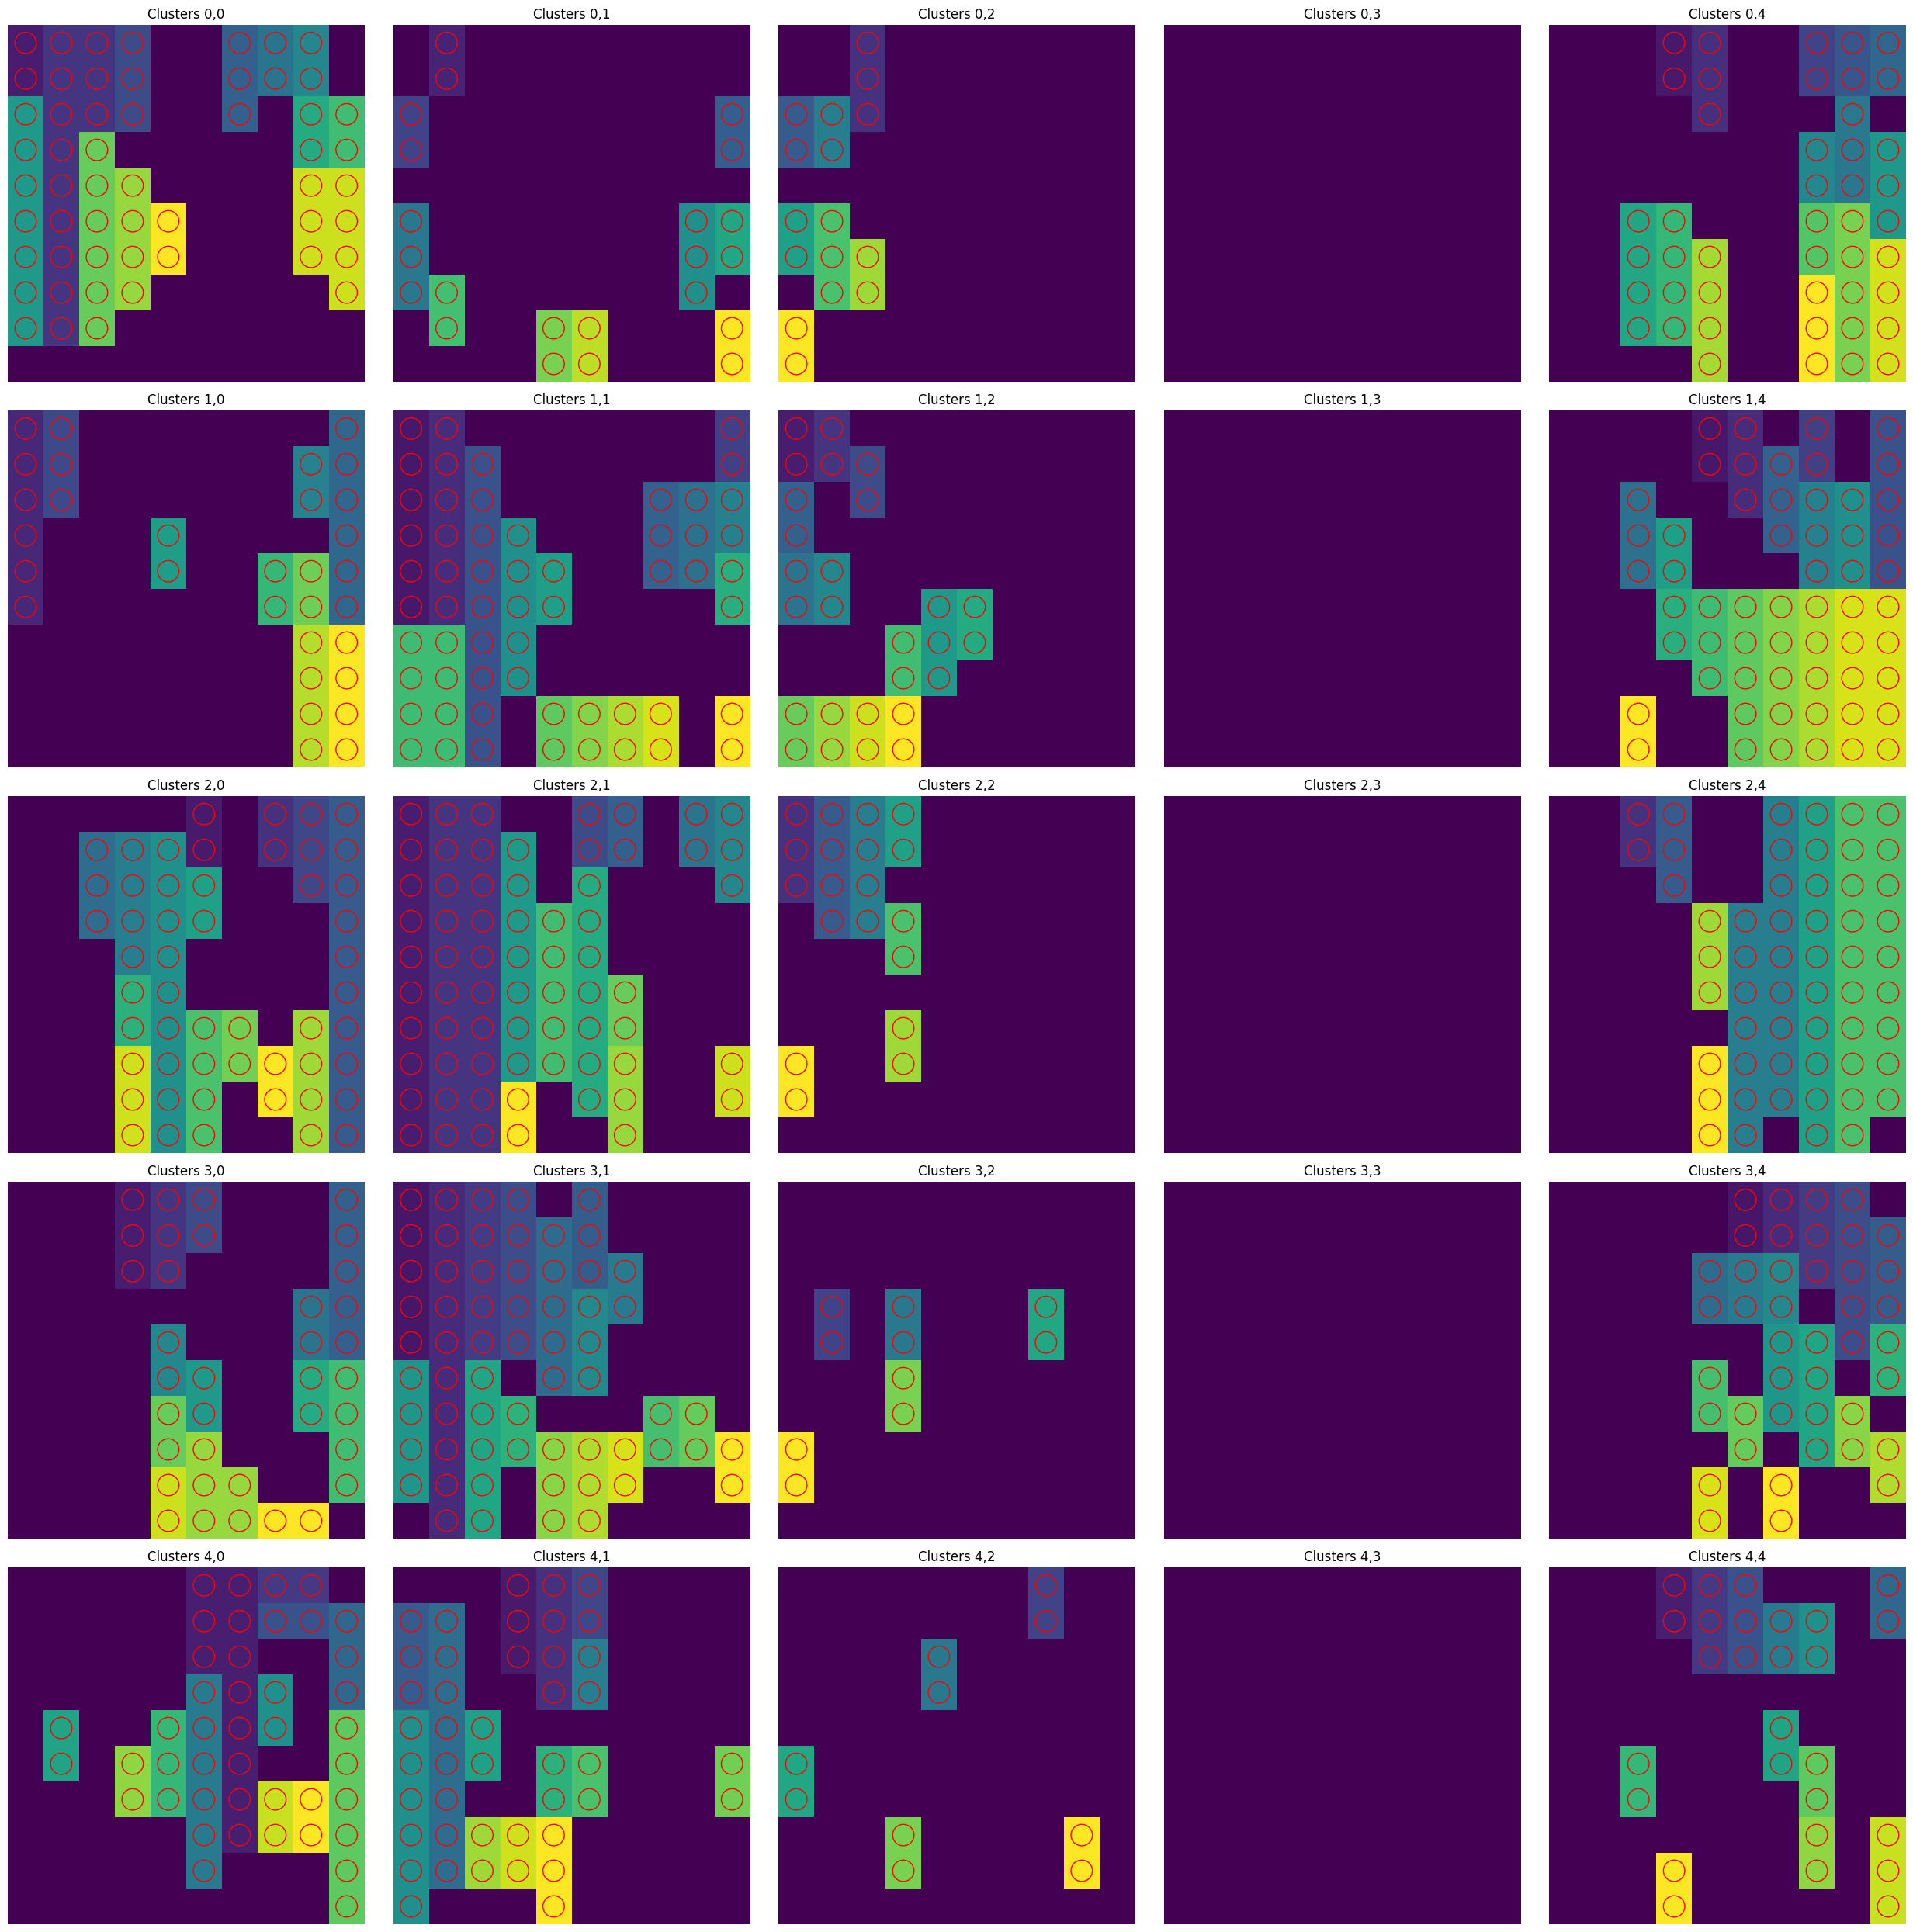

In [13]:
dict_clusters,dict_labels,core_points=DBSCAN_DP(longitude_max = longitude_max,latitude_max = latitude_max,step=step,width=width,eps=10,min_samples=2)
affichage_clusters_enhanced(dict_labels,core_points,longitude_max,latitude_max,width)

regrouper

In [14]:
processed_labels=set()
running_max_label=np.max(dict_labels["labels(0,0)"])

for i in range(longitude_max):
    for j in range(latitude_max):
        if i+1<longitude_max:
            running_max_label,processed_labels,_=merge_clusters_if_shared_core_point(i, j, i+1, j, core_points, dict_labels, step, width,running_max_label,processed_labels)
            
        if j+1<latitude_max:
            running_max_label,processed_labels,_=merge_clusters_if_shared_core_point(i, j, i, j+1, core_points, dict_labels, step, width,running_max_label,processed_labels)
        

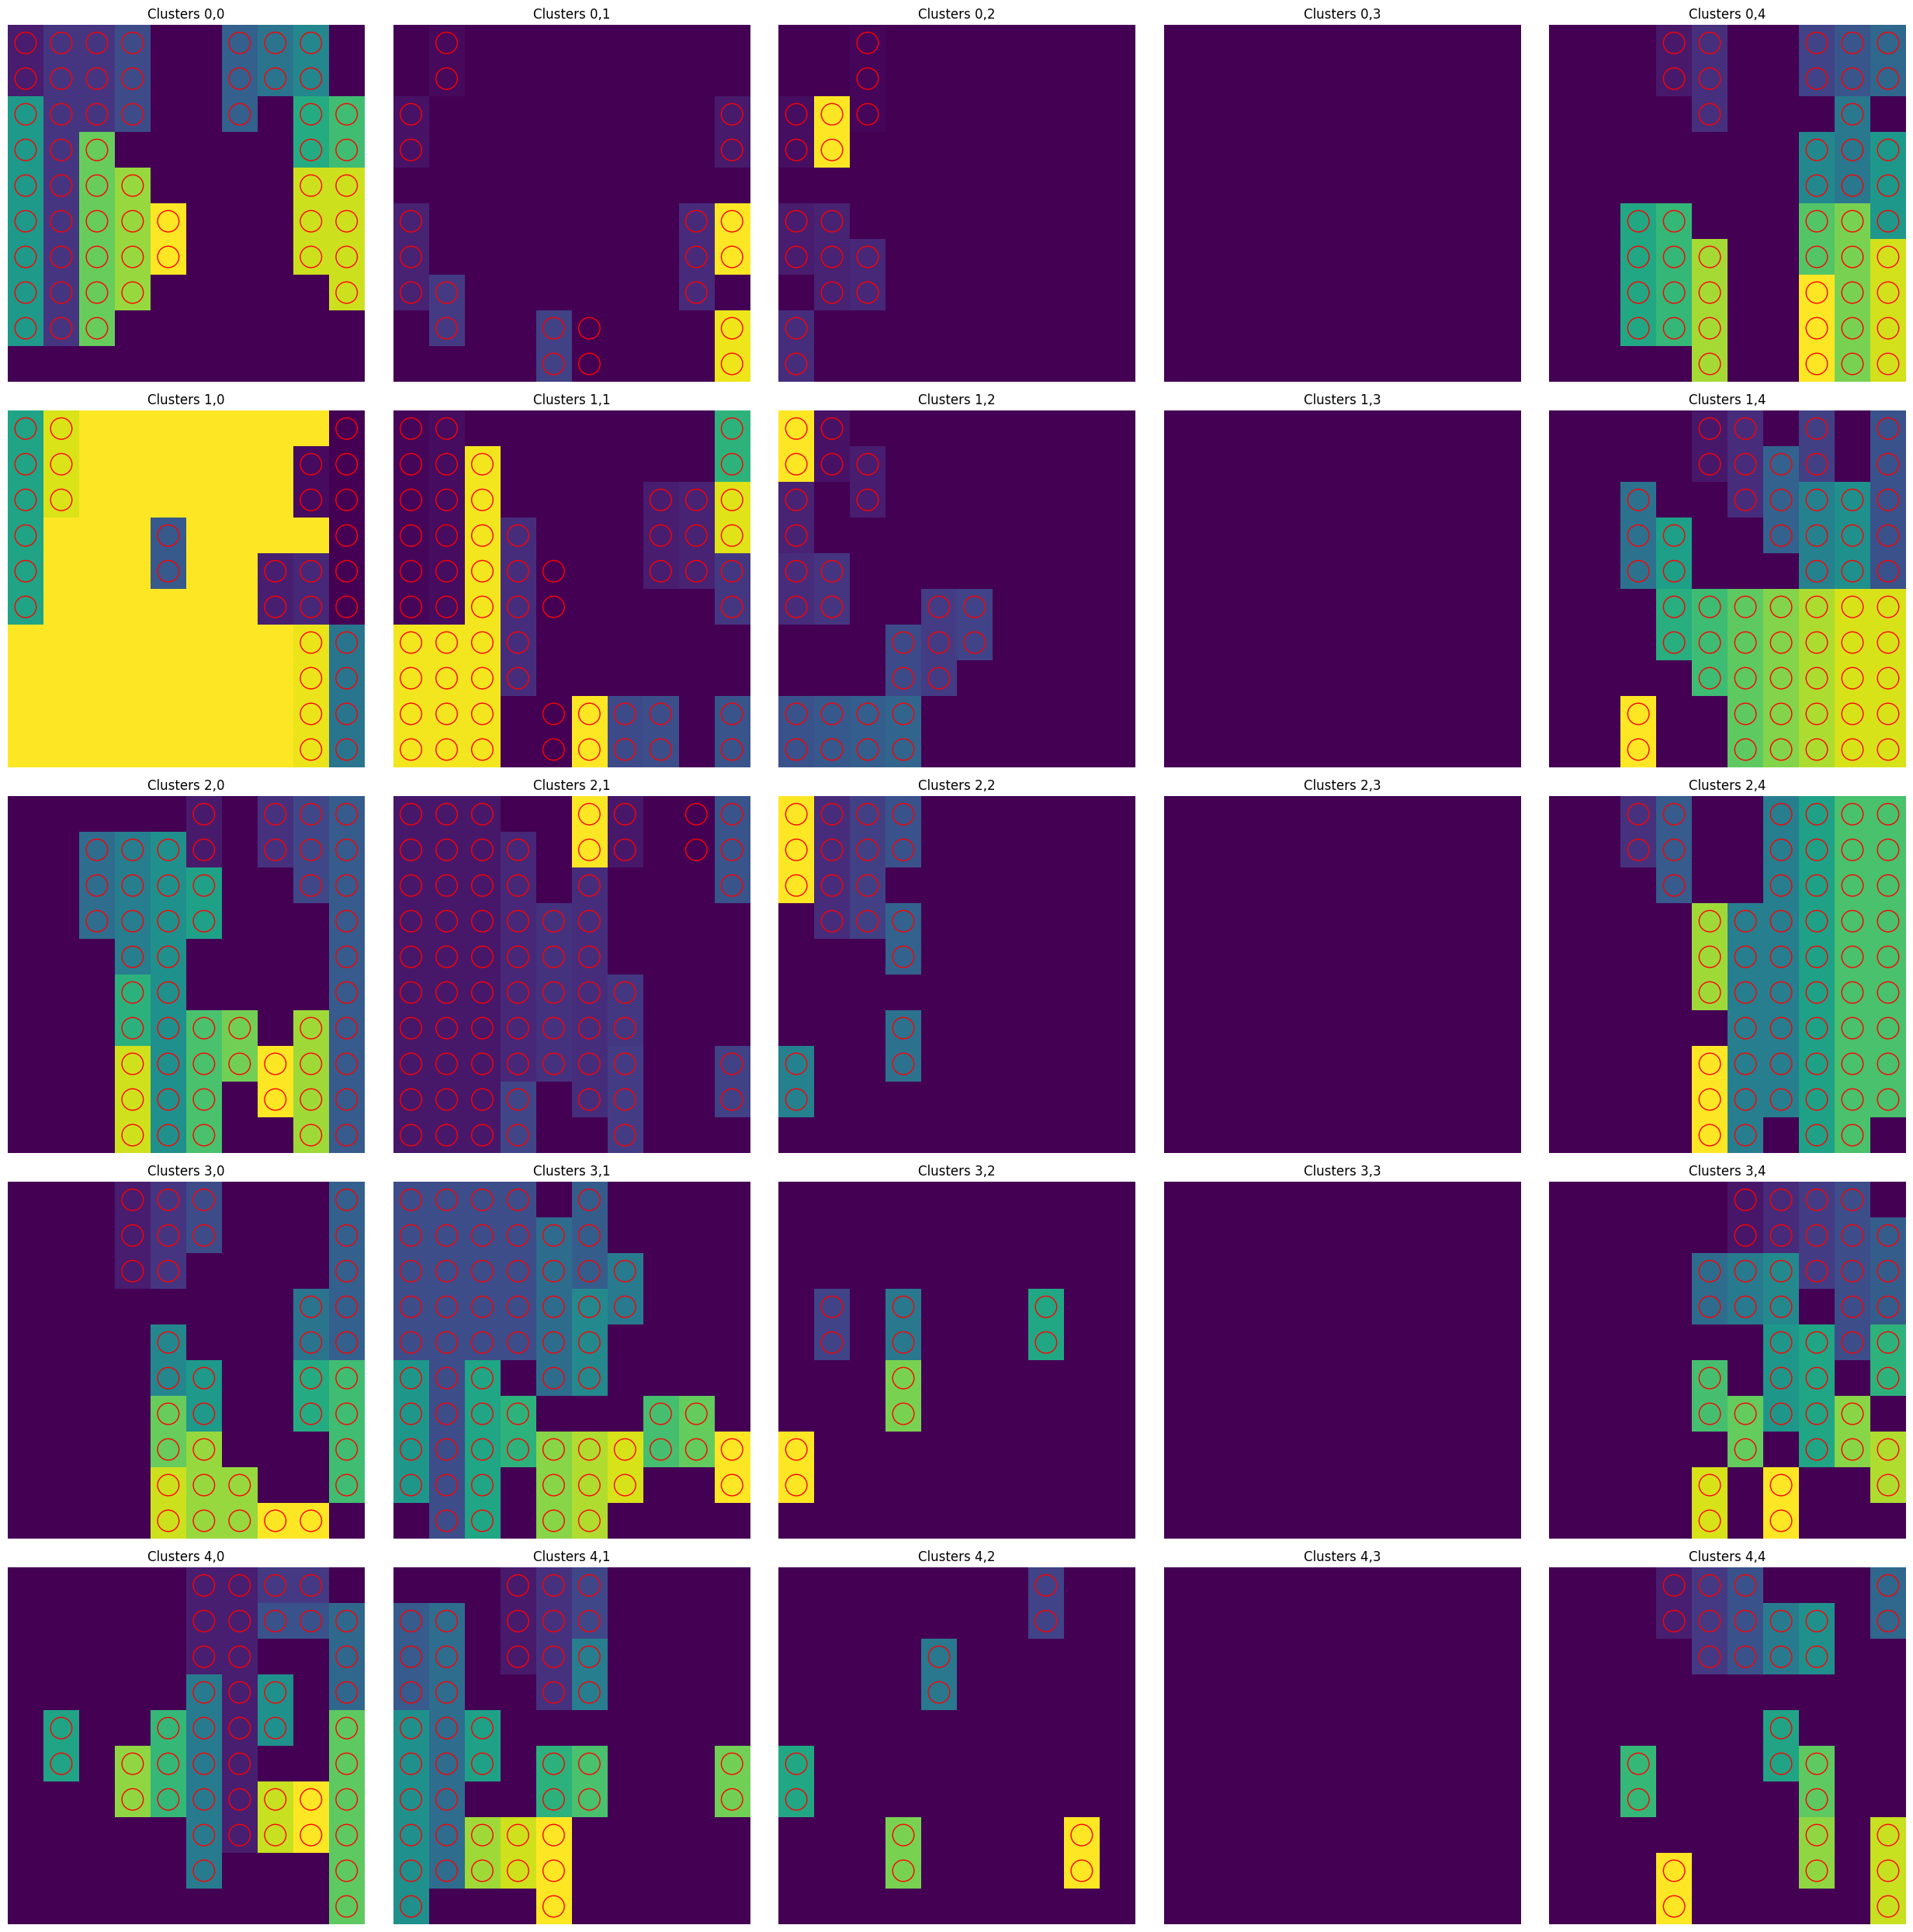

In [15]:
affichage_clusters_enhanced(dict_labels,core_points,longitude_max,latitude_max,width)


In [25]:
pickle_file="distance_matrices_width=10_step=9_longitude=33_latitude=33.pkl"

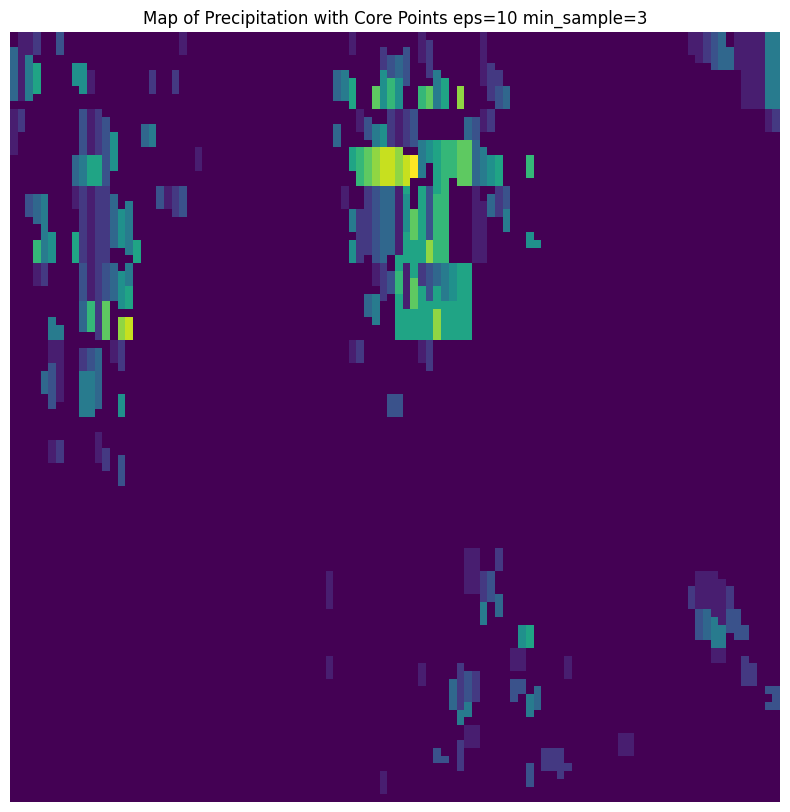

In [3]:
full_map=generate_final_cluster_map(pickle_file,longitude_max=10,latitude_max=10,eps=10,min_samples=3, min_cluster_size=0)

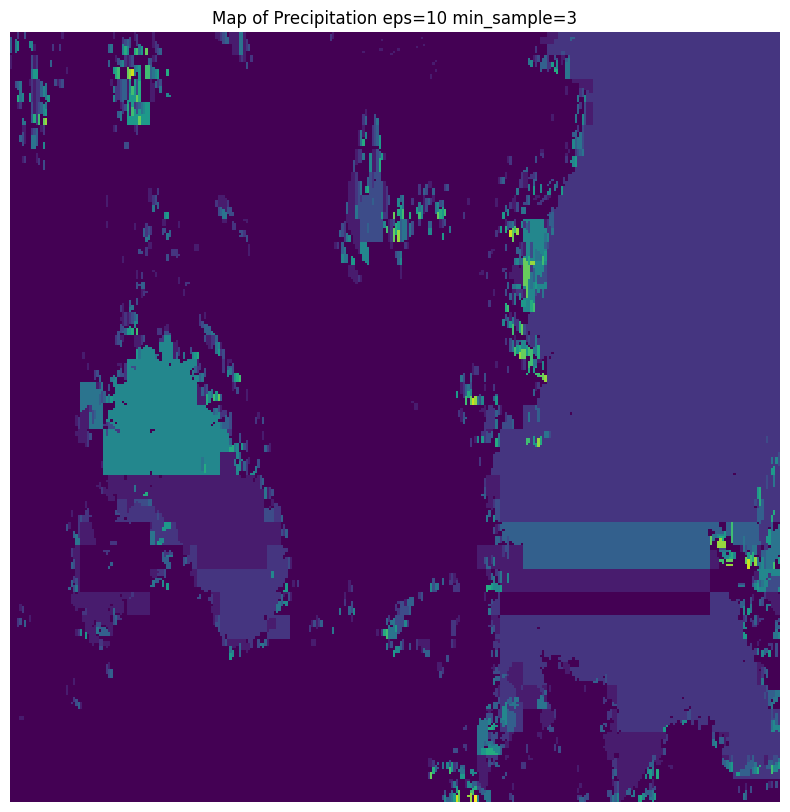

In [26]:
full_map=generate_final_cluster_map(pickle_file,eps=10,min_samples=3, min_cluster_size=20)

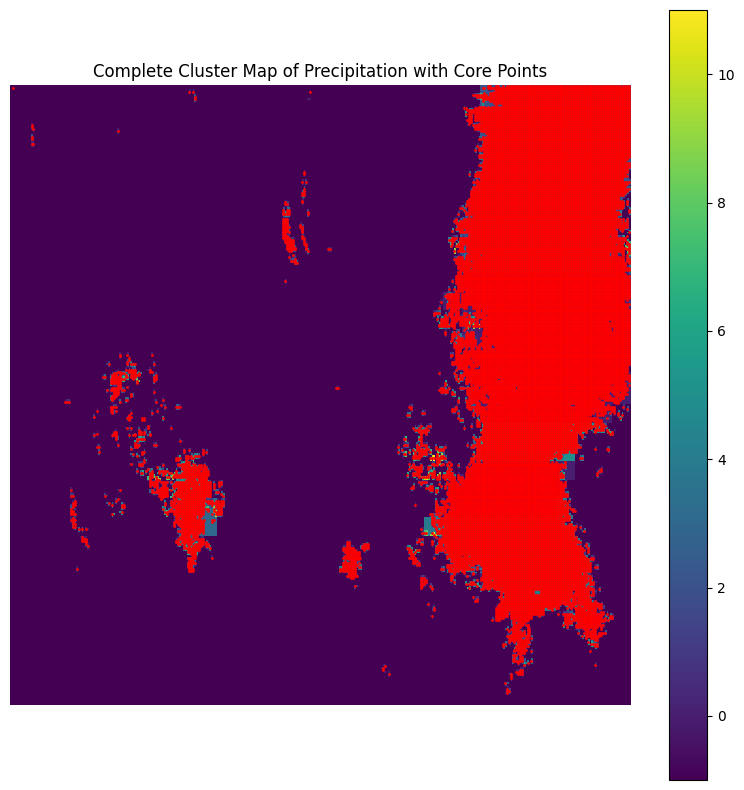

In [99]:
full_map=generate_final_cluster_map(pickle_file, longitude_max=33, latitude_max=33, step=9, width=10, eps=7, min_samples=3, show_core_points=True)

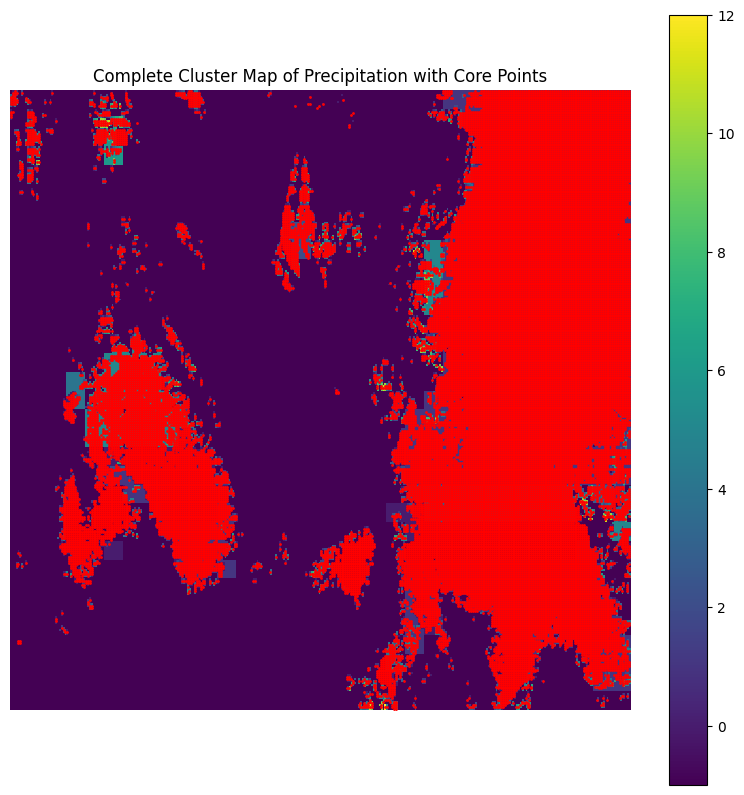

In [100]:
full_map=generate_final_cluster_map(pickle_file, longitude_max=33, latitude_max=33, step=9, width=10, eps=10, min_samples=3, show_core_points=True)

hypothese sur les formes plotot carre en qq endroit: 1/ Comme j'ai mis les points sur les extreme de liaison c'est facile d'avoir des coupures caree car chaqu point est moin en rapport avec un seul cote donc moin de chance de tombe sur une liaison que les autres donc on a plus souvent des coupes come ça qui theoriquement s'ammeillore avec l'augmentation de la marge entre les coupes

different test

test de geometrie de coupe

In [27]:
pickle_file="distance_matrices_width=10_step=8_longitude=37_latitude=37.pkl"


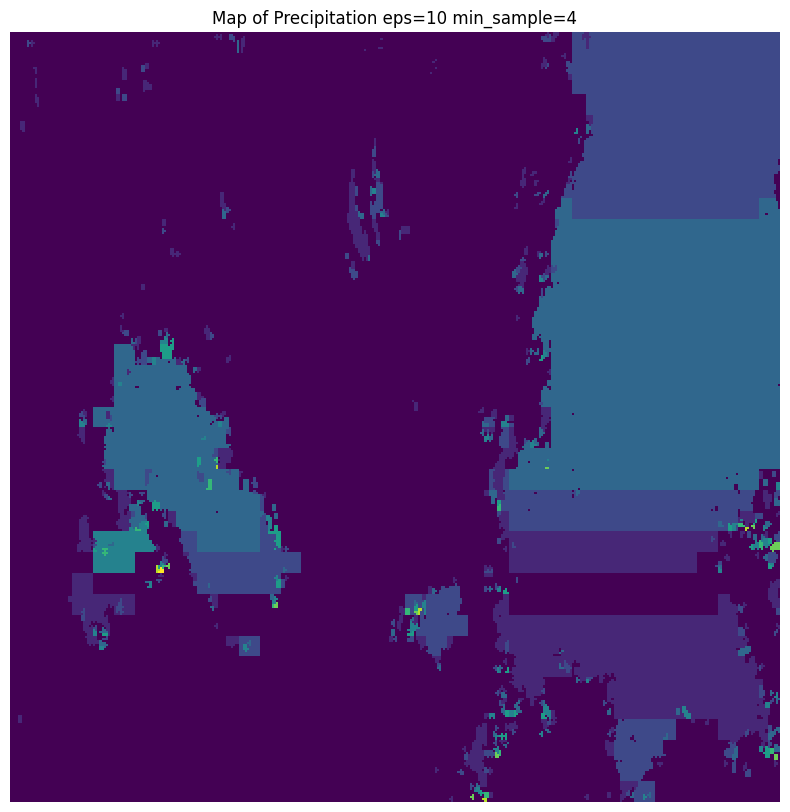

In [28]:
full_map=generate_final_cluster_map(pickle_file, longitude_max=37, latitude_max=37, step=8, width=10, eps=10, min_samples=4, show_core_points=False)

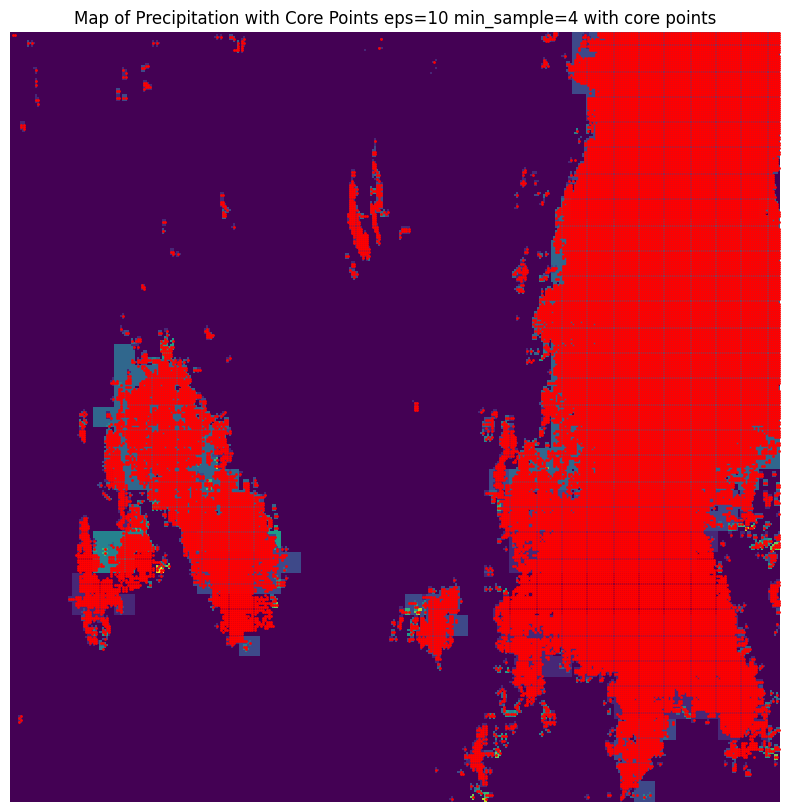

In [157]:
full_map=generate_final_cluster_map(pickle_file, longitude_max=37, latitude_max=37, step=8, width=10, eps=10, min_samples=4, show_core_points=True)

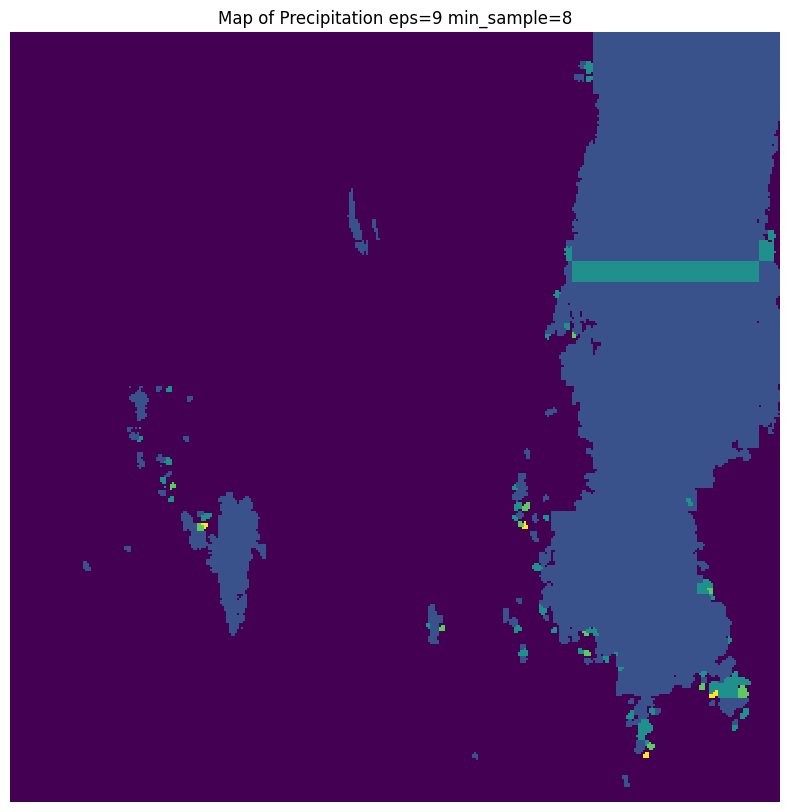

In [29]:
full_map=generate_final_cluster_map(pickle_file, longitude_max=37, latitude_max=37, step=8, width=10, eps=9, min_samples=8, show_core_points=False)

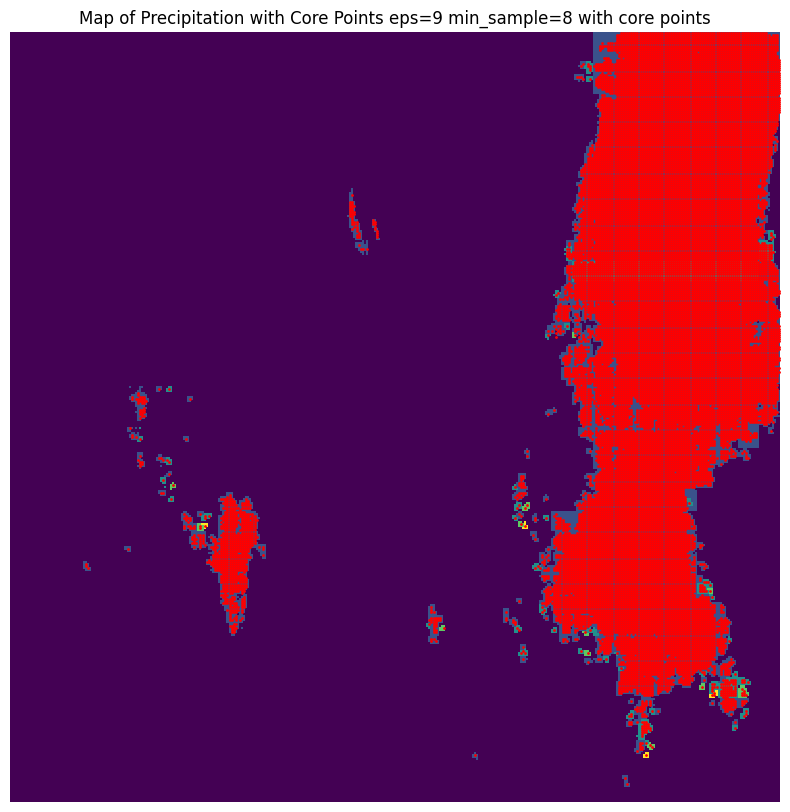

In [23]:
full_map=generate_final_cluster_map(pickle_file, longitude_max=37, latitude_max=37, step=8, width=10, eps=9, min_samples=8, show_core_points=True)

In [159]:
pickle_file="distance_matrices_width=10_step=7_longitude=42_latitude=42.pkl"

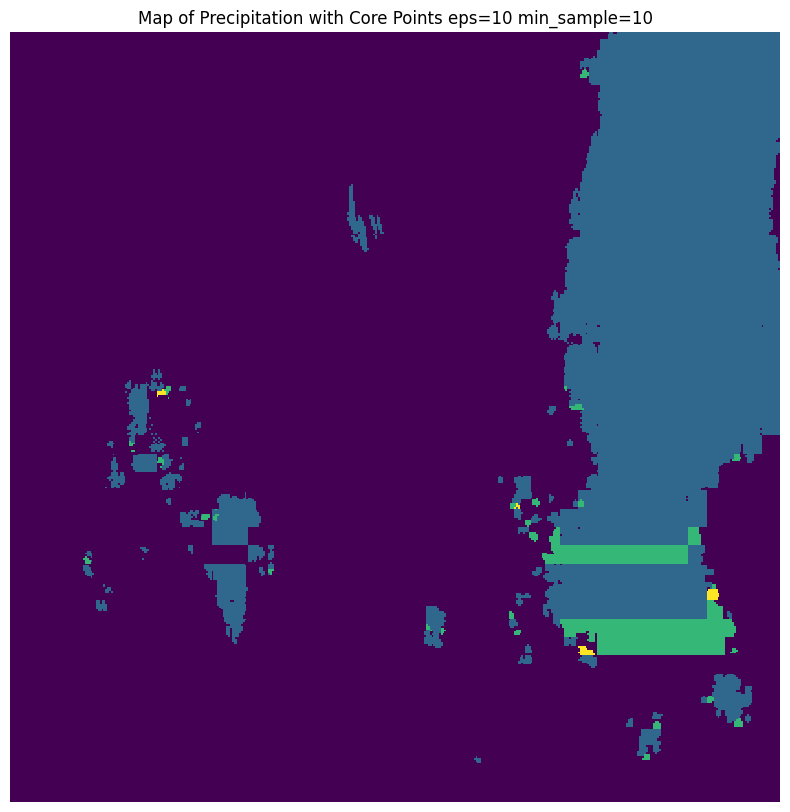

In [160]:
full_map=generate_final_cluster_map(pickle_file, longitude_max=42, latitude_max=42, step=7, width=10, eps=10, min_samples=10, show_core_points=False)

temps

In [33]:
pickle_file="distance_matrices_width=10_step=8_longitude=37_latitude=37_20180201.pkl"


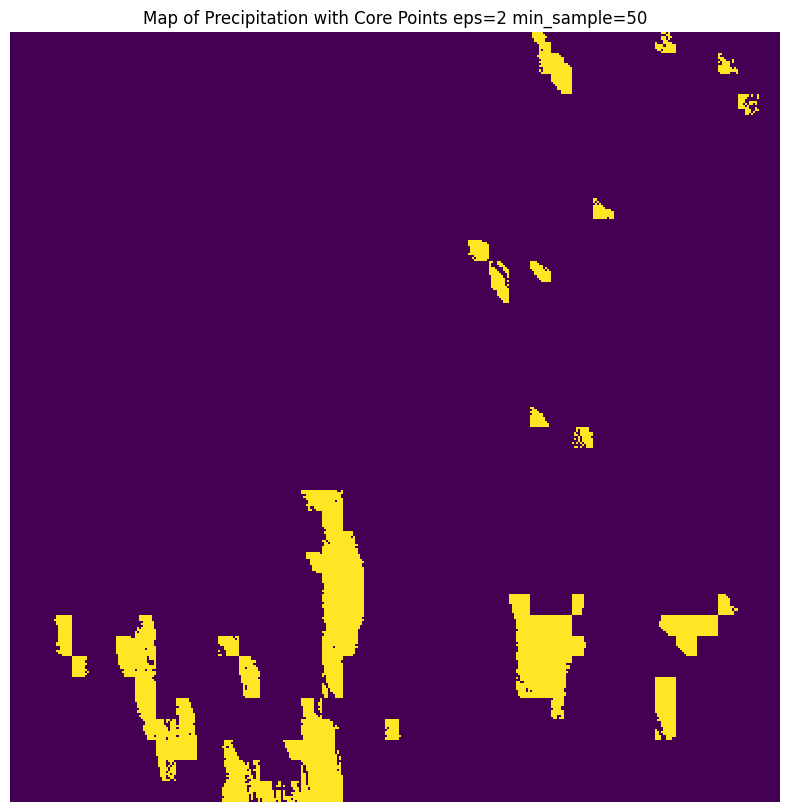

In [162]:
full_map=generate_final_cluster_map(pickle_file, longitude_max=37, latitude_max=37, step=8, width=10, eps=2, min_samples=50, show_core_points=False)

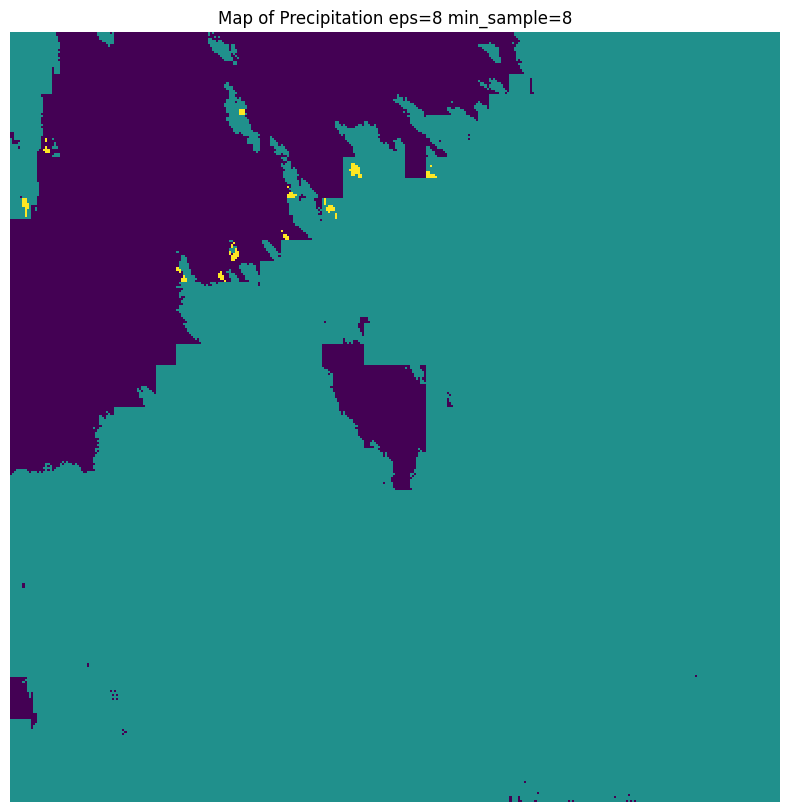

In [52]:
full_map=generate_final_cluster_map(pickle_file, longitude_max=37, latitude_max=37, step=8, width=10, eps=8, min_samples=8, show_core_points=False)

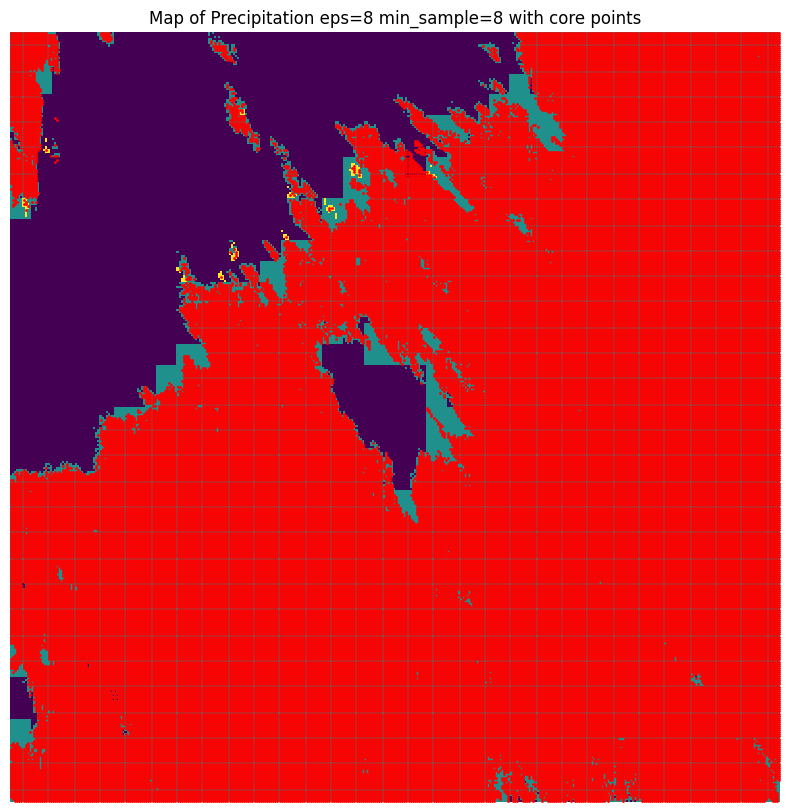

In [48]:
full_map=generate_final_cluster_map(pickle_file, longitude_max=37, latitude_max=37, step=8, width=10, eps=8, min_samples=8, show_core_points=True)

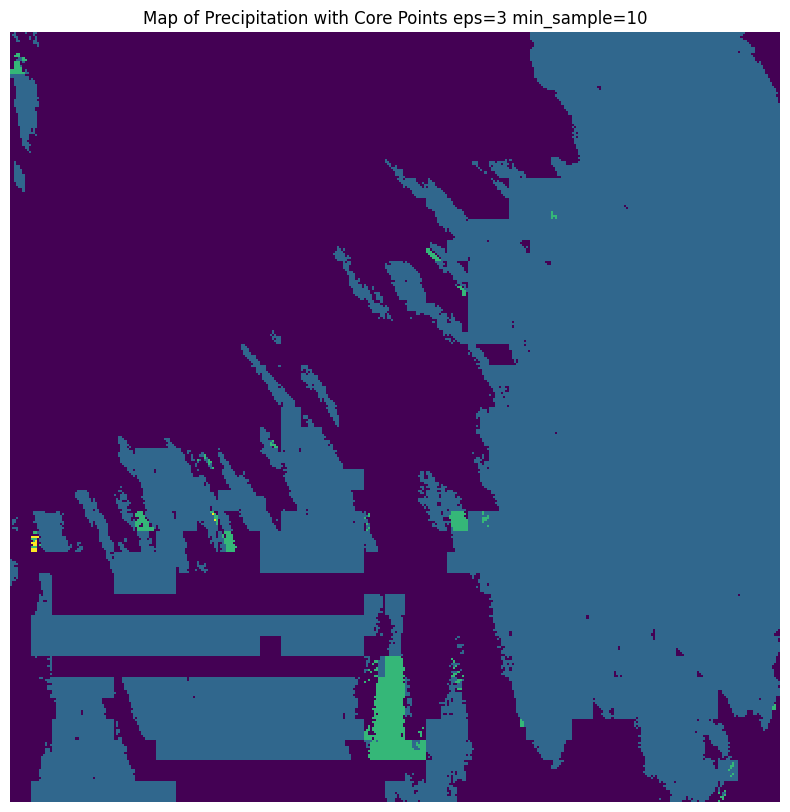

In [164]:
full_map=generate_final_cluster_map(pickle_file, longitude_max=37, latitude_max=37, step=8, width=10, eps=3, min_samples=10, show_core_points=False)

In [30]:
pickle_file="distance_matrices_width=10_step=8_longitude=37_latitude=37_20180206.pkl"

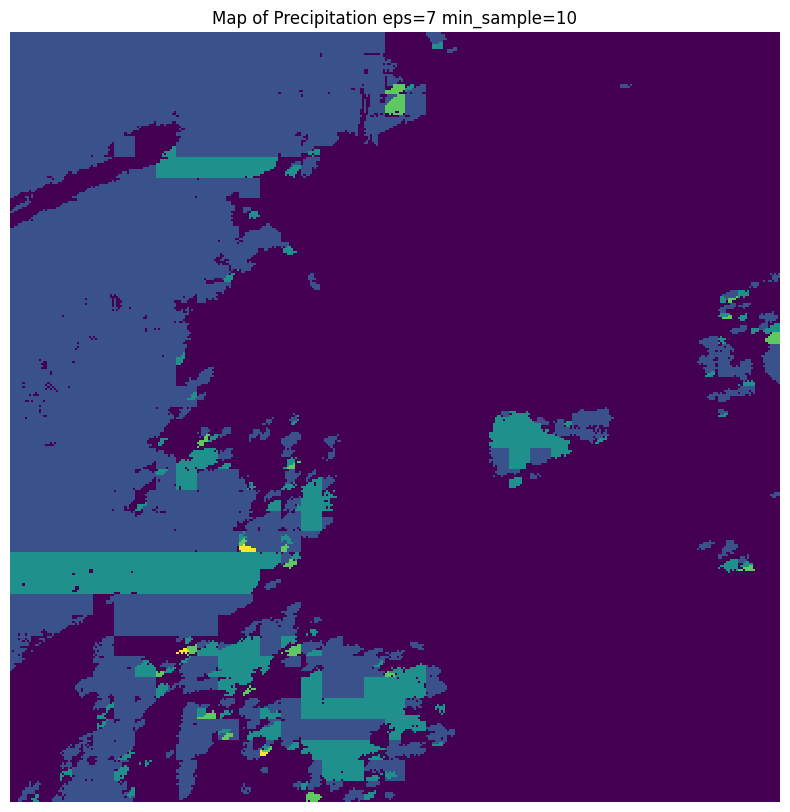

array([[ 0.,  0.,  0., ..., -1., -1., -1.],
       [ 0.,  0.,  0., ..., -1., -1., -1.],
       [ 0.,  0.,  0., ..., -1., -1., -1.],
       ...,
       [-1., -1., -1., ..., -1., -1., -1.],
       [-1., -1., -1., ..., -1., -1., -1.],
       [-1., -1., -1., ..., -1., -1., -1.]])

In [31]:
generate_final_cluster_map(pickle_file, longitude_max=37, latitude_max=37, step=8, width=10, eps=7, min_samples=10, show_core_points=False)

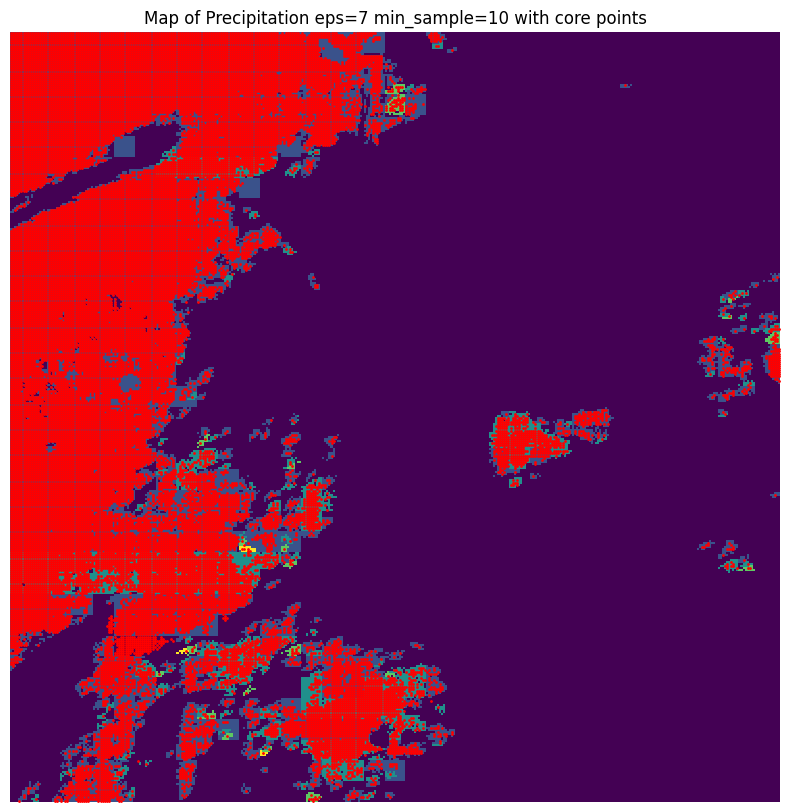

array([[ 0.,  0.,  0., ..., -1., -1., -1.],
       [ 0.,  0.,  0., ..., -1., -1., -1.],
       [ 0.,  0.,  0., ..., -1., -1., -1.],
       ...,
       [-1., -1., -1., ..., -1., -1., -1.],
       [-1., -1., -1., ..., -1., -1., -1.],
       [-1., -1., -1., ..., -1., -1., -1.]])

In [32]:
generate_final_cluster_map(pickle_file, longitude_max=37, latitude_max=37, step=8, width=10, eps=7, min_samples=10, show_core_points=True)

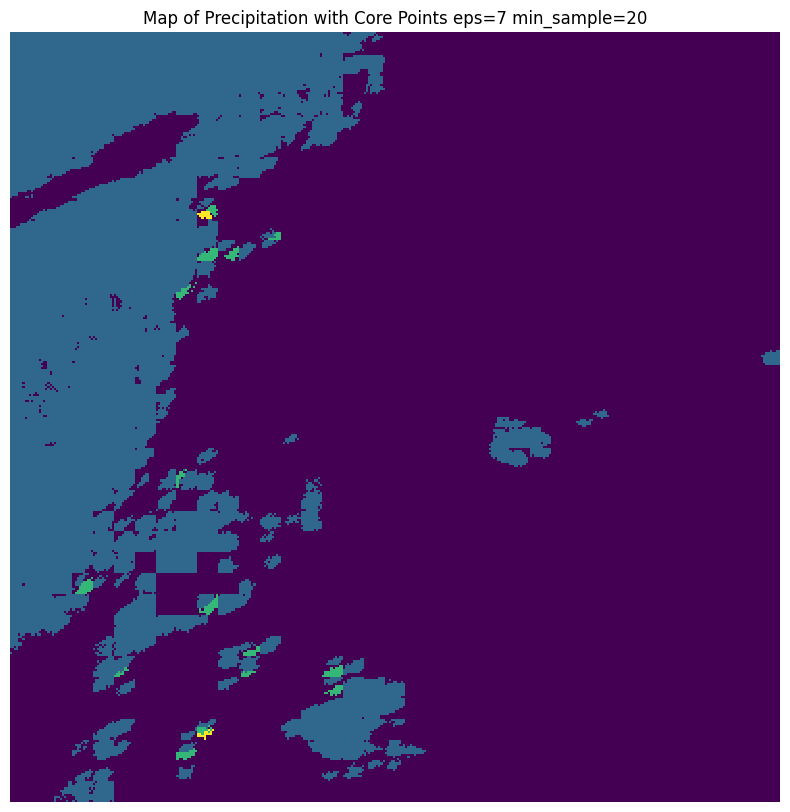

array([[ 0.,  0.,  0., ..., -1., -1., -1.],
       [ 0.,  0.,  0., ..., -1., -1., -1.],
       [ 0.,  0.,  0., ..., -1., -1., -1.],
       ...,
       [-1., -1., -1., ..., -1., -1., -1.],
       [-1., -1., -1., ..., -1., -1., -1.],
       [-1., -1., -1., ..., -1., -1., -1.]])

In [168]:
generate_final_cluster_map(pickle_file, longitude_max=37, latitude_max=37, step=8, width=10, eps=7, min_samples=20, show_core_points=False)